# Gas temperature and cold-gas diagnostics — AIDA-TNG (L35n1080 / 50A)

replace our `SFR > 0` proxy for cold gas with a physically defined temperature cut.
Use **temet**

**Temperatures**:
- `temp` — real gas T from InternalEnergy and ElectronAbundance; for SF cells returns the fake eEOS effective T
- `temp_sfcold` — same as `temp` for non-SF cells; for SF cells replaces T with the SH03 subgrid cold-phase T (1000 K)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from pathlib import Path
import colorsys

import temet
from galaxy_sidm.observables import measure_density_profile

plt.rcParams.update({
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'figure.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

NB_DIR = Path('/leonardo/home/userexternal/acosta01/master_thesis_project/notebooks/AIDA-TNG')
FIG_DIR = NB_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)

h = 0.6774

model_colors = {'CDM': 'black', 'SIDM1': 'tab:blue', 'vSIDM': 'tab:orange'}

SNAP = 67
T_COLD = 10**4.5

In [ ]:
NAMES = ['CDM', 'SIDM1', 'vSIDM']

sims = {
    name: temet.sim(run='aida', variant=name, res=1080, snap=SNAP)
    for name in NAMES
}
for name, sim in sims.items():
    print(f'{name:6s}  {sim.simName}  z={sim.redshift:.3f}  path={sim.simPath}')

CDM     AIDA-L35n1080-CDM  z=0.500  path=/leonardo_work/CNHPC_1478837/AIDA/L35n1080/L35n1080_CDM/output/
SIDM1   AIDA-L35n1080-SIDM1  z=0.500  path=/leonardo_work/CNHPC_1478837/AIDA/L35n1080/L35n1080_SIDM1/output/
vSIDM   AIDA-L35n1080-vSIDM  z=0.500  path=/leonardo_work/CNHPC_1478837/AIDA/L35n1080/L35n1080_vSIDM_correa/output/


## Pick a representative halo
MW-mass halo from CDM (M200c ≈ 10^12 Msun)

In [3]:
sim_cdm = sims['CDM']

# Load halo catalog: M200c and stellar mass of central subhalo
halos = sim_cdm.groupCat(fieldsHalos=['Group_M_Crit200', 'Group_R_Crit200', 'GroupFirstSub'])
sub_mtype = sim_cdm.groupCat(fieldsSubhalos='SubhaloMassType')  # ndarray (N_sub, 6)

m200 = halos['Group_M_Crit200'] * 1e10 / h
r200 = halos['Group_R_Crit200'] / h
first_sub = halos['GroupFirstSub']

mstar = np.zeros(halos['count'])
valid = (first_sub >= 0) & (first_sub < len(sub_mtype))
mstar[valid] = sub_mtype[first_sub[valid], 4] * 1e10 / h

# MW-ish: 10^11.8 < M200c < 10^12.2
sel = (m200 > 10**11.8) & (m200 < 10**12.2) & (mstar > 1e8)
cands = np.where(sel)[0]
hid = int(cands[0])
print(f'Selected haloID={hid}: M200c={m200[hid]:.2e} Msun, R200c={r200[hid]:.1f} kpc, M*={mstar[hid]:.2e} Msun')

Selected haloID=85: M200c=1.57e+12 Msun, R200c=305.8 kpc, M*=2.09e+10 Msun


## Gas phase diagram (log T vs log ρ)

the eEOS ridge should be visible as a narrow density-temperature track (the SH03 subgrid line). SF cells sit on it and have *fake* temperatures. Non-SF cells scatter around it following real cooling/heating.

Two panels: left uses raw `temp` (SF cells sit on the eEOS); right uses `temp_sfcold` (SF cells pulled down to 1000 K).

In [4]:
# Load gas cells belonging to this halo (FoF). temet handles offsets automatically.
gas = {}
gas['temp']        = sim_cdm.snapshotSubset('gas', 'temp',            haloID=hid)
gas['temp_sfcold'] = sim_cdm.snapshotSubset('gas', 'temp_sfcold',     haloID=hid)
gas['rho']         = sim_cdm.snapshotSubset('gas', 'Density',         haloID=hid)
gas['mass']        = sim_cdm.snapshotSubset('gas', 'Masses',          haloID=hid)
gas['sfr']         = sim_cdm.snapshotSubset('gas', 'StarFormationRate', haloID=hid)
gas['pos']         = sim_cdm.snapshotSubset('gas', 'Coordinates',     haloID=hid)

print(f'{len(gas["temp"])} gas cells in halo {hid}')
print(f'SF cells (SFR>0): {(gas["sfr"] > 0).sum()}')
print(f'log T range (raw):        {np.log10(gas["temp"].min()):.2f} to {np.log10(gas["temp"].max()):.2f}')
print(f'log T range (sfcold):     {np.log10(gas["temp_sfcold"].min()):.2f} to {np.log10(gas["temp_sfcold"].max()):.2f}')
print(f'median T for SF cells (raw):    {np.median(gas["temp"][gas["sfr"]>0]):.1f} K')
print(f'median T for SF cells (sfcold): {np.median(gas["temp_sfcold"][gas["sfr"]>0]):.1f} K')

426966 gas cells in halo 85
SF cells (SFR>0): 23198
log T range (raw):        3.93 to 7.37
log T range (sfcold):     3.00 to 7.37
median T for SF cells (raw):    17261.2 K
median T for SF cells (sfcold): 1000.0 K


/tmp/ipykernel_3826671/2204588984.py:25: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Roboto.
  plt.tight_layout()
/tmp/ipykernel_3826671/2204588984.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_3826671/2204588984.py:26: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Roboto.
  plt.savefig(FIG_DIR / f'gastemp_phasediagram_halo{hid}.pdf', dpi=150, bbox_inches='tight')
/leonardo/home/userexternal/acosta01/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Roboto.
  fig.canvas.print_figure(bytes_io, **kw)


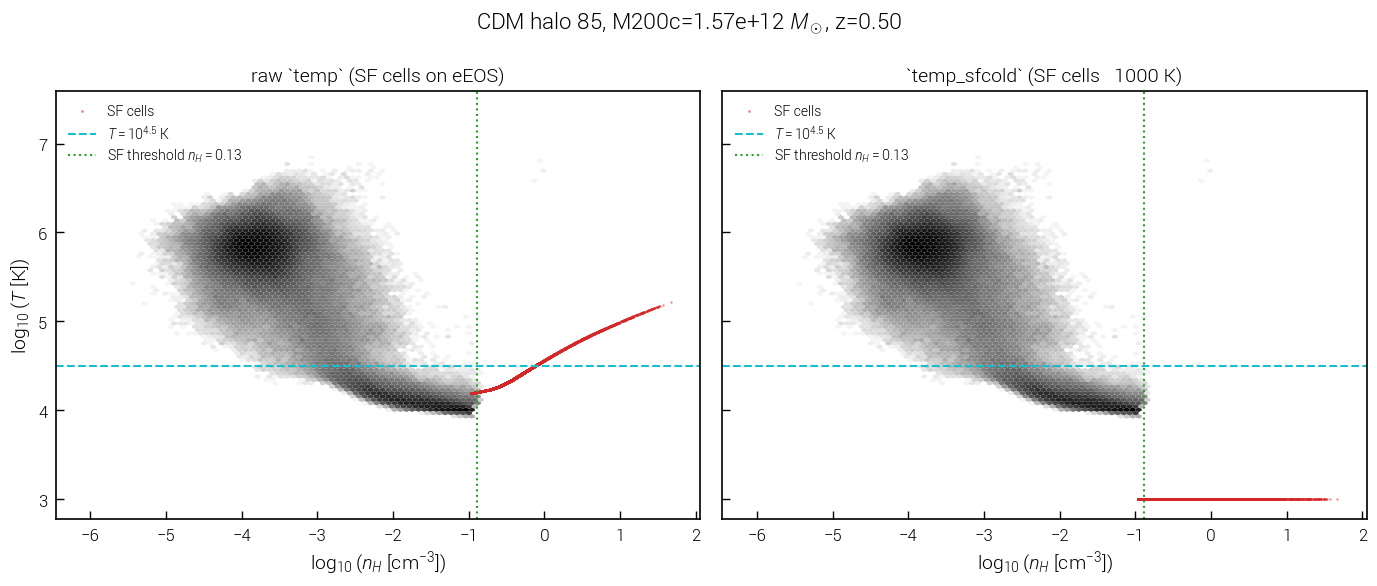

In [5]:
# Density is comoving in code units; convert to physical nH.
a = 1.0 / (1.0 + sim_cdm.redshift)
rho_Msun_kpc3 = gas['rho'] * 1e10 * h**2 / a**3
nH = rho_Msun_kpc3 * 3.08e-8

log_nH = np.log10(np.maximum(nH, 1e-10))
log_T_raw    = np.log10(np.maximum(gas['temp'], 1.0))
log_T_sfcold = np.log10(np.maximum(gas['temp_sfcold'], 1.0))
is_sf = gas['sfr'] > 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, logT, title in [(axes[0], log_T_raw,    'raw `temp` (SF cells on eEOS)'),
                         (axes[1], log_T_sfcold, '`temp_sfcold` (SF cells → 1000 K)')]:
    ax.hexbin(log_nH[~is_sf], logT[~is_sf], gridsize=80, mincnt=1, cmap='Greys', bins='log')
    ax.scatter(log_nH[is_sf], logT[is_sf], s=3, color='tab:red', alpha=0.5, label='SF cells')
    ax.axhline(np.log10(T_COLD), color='tab:cyan', ls='--', lw=1.5, label=r'$T=10^{4.5}$ K')
    ax.axvline(np.log10(0.13), color='tab:green', ls=':', lw=1.5, label=r'SF threshold $n_H=0.13$')
    ax.set_xlabel(r'$\log_{10}(n_H\ [\mathrm{cm}^{-3}])$')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=10)

axes[0].set_ylabel(r'$\log_{10}(T\ [\mathrm{K}])$')
fig.suptitle(f'CDM halo {hid}, M200c={m200[hid]:.2e} $M_\\odot$, z={sim_cdm.redshift:.2f}')
plt.tight_layout()
plt.savefig(FIG_DIR / f'gastemp_phasediagram_halo{hid}.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Temperature histograms stratified by SFR status

/tmp/ipykernel_3010450/1207566214.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


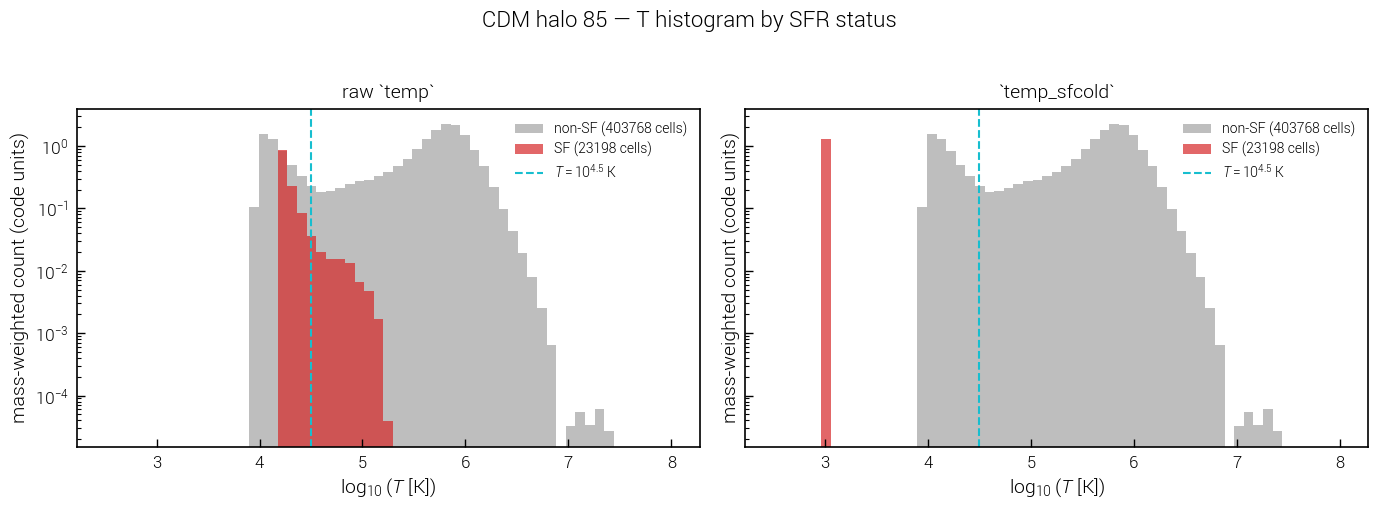

In [6]:
bins = np.linspace(2.5, 8.0, 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, logT, title in [(axes[0], log_T_raw,    'raw `temp`'),
                         (axes[1], log_T_sfcold, '`temp_sfcold`')]:
    ax.hist(logT[~is_sf], bins=bins, weights=gas['mass'][~is_sf],
            histtype='stepfilled', alpha=0.5, color='tab:gray', label=f'non-SF ({(~is_sf).sum()} cells)')
    ax.hist(logT[is_sf], bins=bins, weights=gas['mass'][is_sf],
            histtype='stepfilled', alpha=0.7, color='tab:red', label=f'SF ({is_sf.sum()} cells)')
    ax.axvline(np.log10(T_COLD), color='tab:cyan', ls='--', lw=1.5, label=r'$T=10^{4.5}$ K')
    ax.set_xlabel(r'$\log_{10}(T\ [\mathrm{K}])$')
    ax.set_ylabel('mass-weighted count (code units)')
    ax.set_title(title)
    ax.legend(fontsize=10)
    ax.set_yscale('log')

fig.suptitle(f'CDM halo {hid} — T histogram by SFR status', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / f'gastemp_hist_halo{hid}.pdf', dpi=150, bbox_inches='tight')
plt.show()

## How much cold gas does each definition keep?

For a single halo (one snapshot in time), compare the *cold gas mass fraction* under several definitions:

| Definition | What it keeps |
| --- | --- |
| `SFR > 0` | only cells actively forming stars (ISM/SF proxy) |
| `temp < T` | gas below T, using raw temperature (SF cells mostly excluded — fake T above 10^4) |
| `temp_sfcold < T` | gas below T, with SF cells pulled down to 1000 K (SF cells always pass for T ≥ 1000) |

SFR > 0                       0.062
temp < 1e4                    0.022
temp < 10^4.5                 0.282
temp < 1e5                    0.342
temp_sfcold < 1e4             0.083
temp_sfcold < 10^4.5          0.287
temp_sfcold < 1e5             0.343


/tmp/ipykernel_3010450/1385354521.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


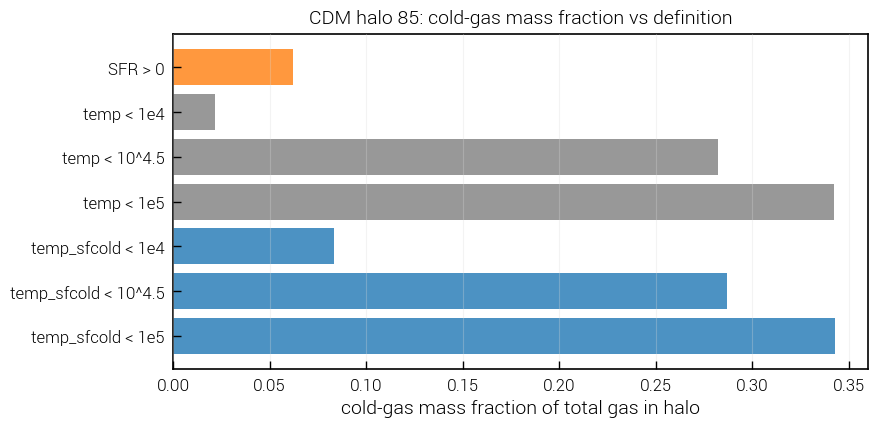

In [7]:
tot = gas['mass'].sum()

defs = [
    ('SFR > 0',               gas['sfr'] > 0),
    ('temp < 1e4',            gas['temp']        < 1e4),
    ('temp < 10^4.5',         gas['temp']        < 10**4.5),
    ('temp < 1e5',            gas['temp']        < 1e5),
    ('temp_sfcold < 1e4',     gas['temp_sfcold'] < 1e4),
    ('temp_sfcold < 10^4.5',  gas['temp_sfcold'] < 10**4.5),
    ('temp_sfcold < 1e5',     gas['temp_sfcold'] < 1e5),
]

labels, fracs = [], []
for label, mask in defs:
    f = gas['mass'][mask].sum() / tot
    print(f'{label:28s}  {f:.3f}')
    labels.append(label); fracs.append(f)

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['tab:orange'] + ['tab:gray']*3 + ['tab:blue']*3
ax.barh(labels, fracs, color=colors, alpha=0.8)
ax.set_xlabel('cold-gas mass fraction of total gas in halo')
ax.set_title(f'CDM halo {hid}: cold-gas mass fraction vs definition')
ax.invert_yaxis()
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / f'gastemp_coldfrac_halo{hid}.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Density profiles under different cold-gas masks

The test that matters for our downstream work: does the **cold gas density profile** change materially when we switch from SFR>0 to a temperature cut? Expectation: yes — significantly at large radii (CGM cold gas), and by a factor at small radii too.

/tmp/ipykernel_3010450/300199727.py:44: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


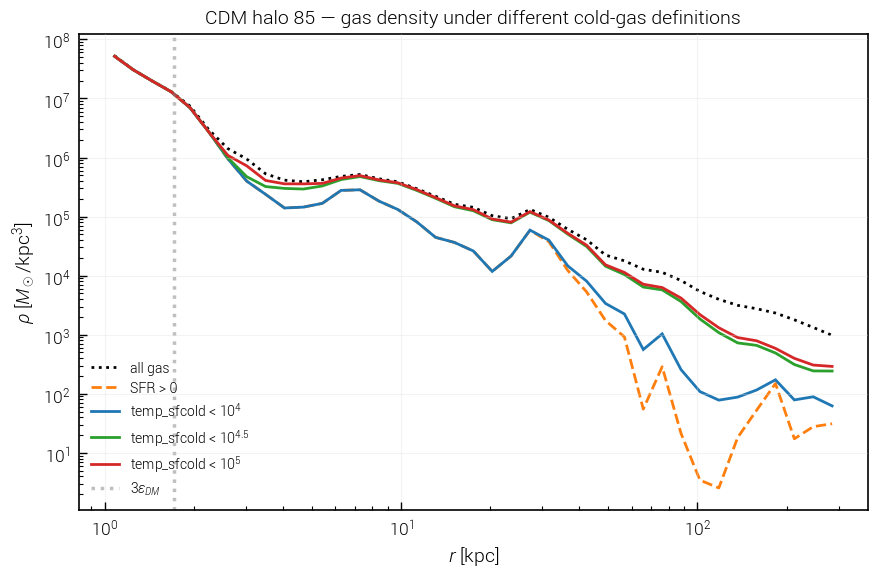

In [8]:
# Compute halo-centric radii in physical kpc
halo_single = sim_cdm.halo(hid)
halo_pos = halo_single['GroupPos']
box = sim_cdm.boxSize
dx = gas['pos'] - halo_pos
dx -= box * np.round(dx / box)
r_kpc = np.linalg.norm(dx, axis=1) / h
m_msun = gas['mass'] * 1e10 / h

# Radial bins out to R200c
r_edges = np.logspace(np.log10(1.0), np.log10(r200[hid]), 40)

masks = {
    'all gas':                 np.ones(len(r_kpc), dtype=bool),
    'SFR > 0':                 gas['sfr'] > 0,
    r'temp_sfcold < $10^4$':   gas['temp_sfcold'] < 1e4,
    r'temp_sfcold < $10^{4.5}$': gas['temp_sfcold'] < 10**4.5,
    r'temp_sfcold < $10^5$':   gas['temp_sfcold'] < 1e5,
}

fig, ax = plt.subplots(figsize=(9, 6))
prof_colors = {
    'all gas': 'black',
    'SFR > 0': 'tab:orange',
    r'temp_sfcold < $10^4$': 'tab:blue',
    r'temp_sfcold < $10^{4.5}$': 'tab:green',
    r'temp_sfcold < $10^5$': 'tab:red',
}
for label, mask in masks.items():
    if mask.sum() == 0:
        continue
    _, rho, _ = measure_density_profile(dx[mask] / h, m_msun[mask], r_edges=r_edges)
    r_mid = 0.5 * (r_edges[1:] + r_edges[:-1])
    good = rho > 0
    ls = '-' if 'temp_sfcold' in label else ('--' if label == 'SFR > 0' else ':')
    ax.loglog(r_mid[good], rho[good], label=label, color=prof_colors[label], lw=2, ls=ls)

ax.axvline(3 * 0.57, color='gray', ls=':', alpha=0.5, label=r'$3\epsilon_{DM}$')
ax.set_xlabel(r'$r$ [kpc]')
ax.set_ylabel(r'$\rho$ [$M_\odot$/kpc$^3$]')
ax.set_title(f'CDM halo {hid} — gas density under different cold-gas definitions')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / f'gastemp_profiles_halo{hid}.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Ensemble: median cold-gas profiles over MW-like halos

5/30 halos done
10/30 halos done
15/30 halos done
20/30 halos done
25/30 halos done
30/30 halos done


/tmp/ipykernel_3010450/3850613925.py:53: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


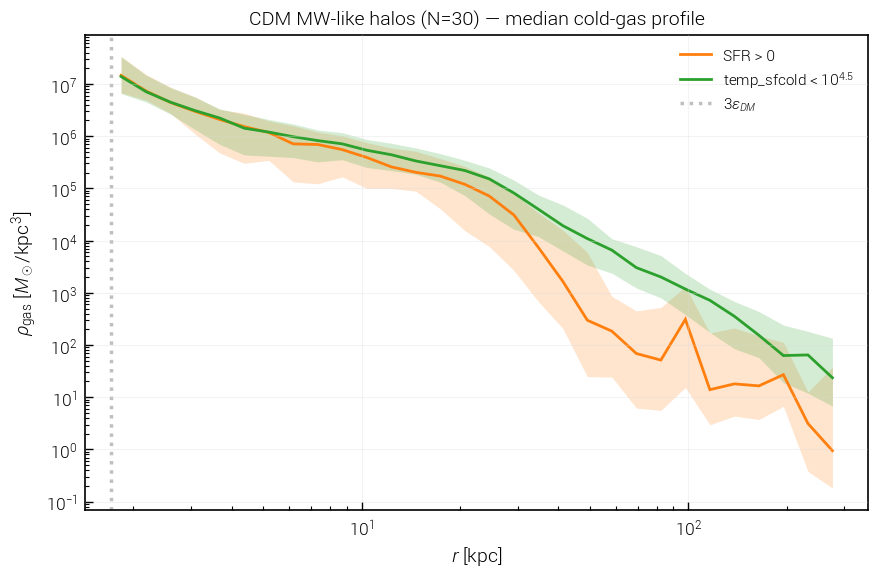

In [9]:
ens_ids = cands[:30]
r_common = np.logspace(np.log10(2.0), np.log10(300.0), 30)
r_edges_ens = np.concatenate([[r_common[0]/1.2], r_common])

ens_defs = {
    'SFR > 0':                    lambda g: g['sfr'] > 0,
    r'temp_sfcold < $10^{4.5}$':  lambda g: g['temp_sfcold'] < 10**4.5,
}
ens_colors = {'SFR > 0': 'tab:orange', r'temp_sfcold < $10^{4.5}$': 'tab:green'}

def halo_gas_profile_mask(sim, hid, halo_pos, mask_fn, r_edges):
    g = {
        'temp_sfcold': sim.snapshotSubset('gas', 'temp_sfcold',       haloID=hid),
        'sfr':         sim.snapshotSubset('gas', 'StarFormationRate', haloID=hid),
        'mass':        sim.snapshotSubset('gas', 'Masses',            haloID=hid),
        'pos':         sim.snapshotSubset('gas', 'Coordinates',       haloID=hid),
    }
    box = sim.boxSize
    dx = g['pos'] - halo_pos
    dx -= box * np.round(dx / box)
    mask = mask_fn(g)
    if mask.sum() == 0:
        return np.zeros(len(r_edges) - 1)
    _, rho, _ = measure_density_profile(dx[mask] / h, g['mass'][mask] * 1e10 / h, r_edges=r_edges)
    return rho

ens_profiles = {k: [] for k in ens_defs}
for i, this_hid in enumerate(ens_ids):
    halo_pos_i = sim_cdm.halo(int(this_hid))['GroupPos']
    for label, mask_fn in ens_defs.items():
        rho = halo_gas_profile_mask(sim_cdm, int(this_hid), halo_pos_i, mask_fn, r_edges_ens)
        ens_profiles[label].append(rho)
    if (i+1) % 5 == 0:
        print(f'{i+1}/{len(ens_ids)} halos done')

fig, ax = plt.subplots(figsize=(9, 6))
r_mid_ens = 0.5 * (r_edges_ens[1:] + r_edges_ens[:-1])
for label, arr_list in ens_profiles.items():
    arr = np.array(arr_list)
    arr[arr == 0] = np.nan
    med = np.nanmedian(arr, axis=0)
    p16 = np.nanpercentile(arr, 16, axis=0)
    p84 = np.nanpercentile(arr, 84, axis=0)
    ax.loglog(r_mid_ens, med, color=ens_colors[label], lw=2, label=label)
    ax.fill_between(r_mid_ens, p16, p84, color=ens_colors[label], alpha=0.2)

ax.axvline(3 * 0.57, color='gray', ls=':', alpha=0.5, label=r'$3\epsilon_{DM}$')
ax.set_xlabel(r'$r$ [kpc]')
ax.set_ylabel(r'$\rho_{\rm gas}$ [$M_\odot$/kpc$^3$]')
ax.set_title(f'CDM MW-like halos (N={len(ens_ids)}) — median cold-gas profile')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'gastemp_profiles_ensemble_cdm.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Takeaways (fill in after running)

- [ ] Does `temp_sfcold < 10^{4.5}` give a *larger* inner-halo gas density than `SFR > 0`? By how much?
- [ ] Does the CGM contribution show up clearly (r > 0.1 R200c) in the temperature-masked profile but not in the SFR mask?
- [ ] Is the difference between `temp_sfcold < 10^4` and `< 10^{4.5}` small enough that the choice of threshold doesn't dominate conclusions?
- [ ] Sanity: SF cell median T should be 1000 K under `temp_sfcold`, and ~10^4 K under raw `temp`.

**Next steps** (do not implement here):
1. Add `measure_cold_gas_profile(basePath, snap, halo_id, r_edges, T_thresh=10**4.5)` in `src/galaxy_sidm/observables/density.py` — using temet.
2. In `01_density_profiles.ipynb`, swap `measure_sf_gas_profile` for the temperature-based one in the DM+stars+gas mosaics.